### Architecture
In this experiment, EfficientNet_B4 is applied to predict the single output for the pawpularity without metadata inclusion. 

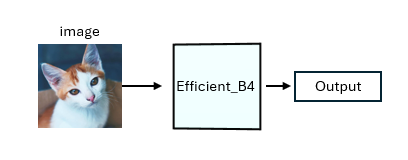

### Analysis
EfficientNet-B4 significantly improves RMSE over B0 in the dominant Pawpularity ranges but shows minor regressions in the high-score tail, suggesting that increased capacity primarily benefits common cases while being more sensitive to noise in rare extreme examples.Higher image resolution (256 to 384) and stronger augmentation with high capcity backbone combinely can improve visual representation quality by learning the richer textures and variations. Additionaly the same EffB4 is trained with LiteAugmentation by keeping all the other params same and resultantly the rmse is reduced. which shows the strong augmentation help the model in improving the overall performance due to model generalization on strong augmentation 


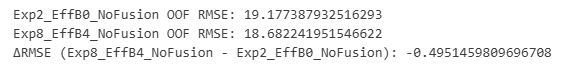

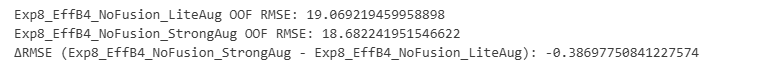

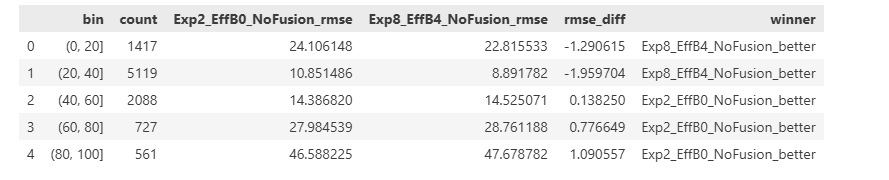

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

In [4]:
#  imports & setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc
import time

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageOnlyDataset
from src.models import build_vision_backbone
from src.train import train_one_epoch_image, validate_image

main_folder = ".."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs", "exp8")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp8"]

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:



kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== Exp8_EffB4_384_Strong: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=32.1940 | ValRMSE: 22.5290
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=20.5371 | ValRMSE: 20.4090
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=19.3393 | ValRMSE: 19.7369
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=18.7819 | ValRMSE: 19.4103
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=18.5714 | ValRMSE: 19.1654
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=18.3443 | ValRMSE: 19.1681
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=18.3401 | ValRMSE: 19.1190
Epoch 8/10 | Fold 1 | Train[MSE]: RMSE=18.1298 | ValRMSE: 19.1289
Epoch 9/10 | Fold 1 | Train[MSE]: RMSE=18.0569 | ValRMSE: 19.0186
Epoch 10/10 | Fold 1 | Train[MSE]: RMSE=17.9683 | ValRMSE: 19.0593
Fold 1 best RMSE: 19.0186

=== Exp8_EffB4_384_Strong: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=31.3373 | ValRMSE: 22.3550
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE=20.4773 | ValRMSE: 20.1778
Epoch 3/10 | Fold 2 | Train[MSE]: RMSE=19.2849 | ValRMSE: 19.5040
Epoch 4/10 | Fold 2 | Train[MSE]: RMS

In [5]:
import pandas
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 19.0186 (n=1983)
Fold 2 OOF RMSE: 18.7857 (n=1983)
Fold 3 OOF RMSE: 18.2169 (n=1982)
Fold 4 OOF RMSE: 18.4870 (n=1982)
Fold 5 OOF RMSE: 18.8915 (n=1982)


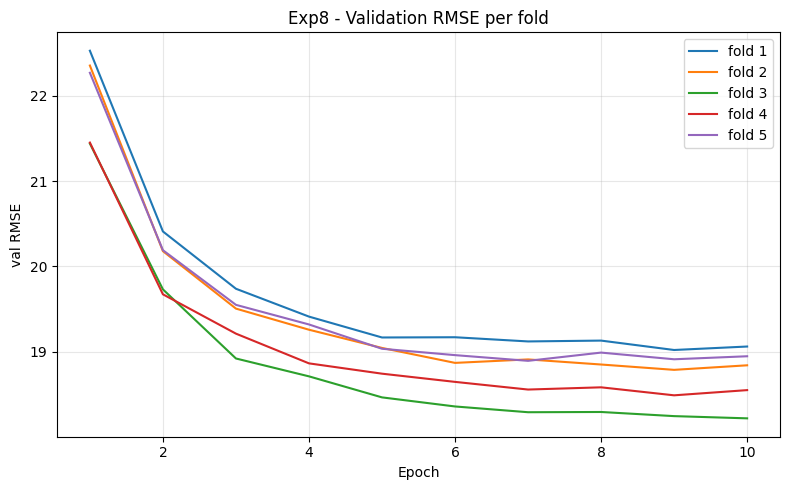

In [6]:
from src.plot import plot_all_folds_history
plot_all_folds_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp8")

In [7]:
# Worst error images 
errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,cda998949ee096e41e190f767561960a,5,12,95.595207,83.595207
1,1791180369993a28ea50e8efb7d48fbc,2,100,25.455618,74.544382
2,88e843485e9dcff9d723ce086e4e026b,2,100,26.311687,73.688313
3,2fd7cda16cb627069fef31c09d7d6b66,1,100,26.498672,73.501328
4,4ff535553cc719ba0e4a59e591285da8,1,100,27.551964,72.448036


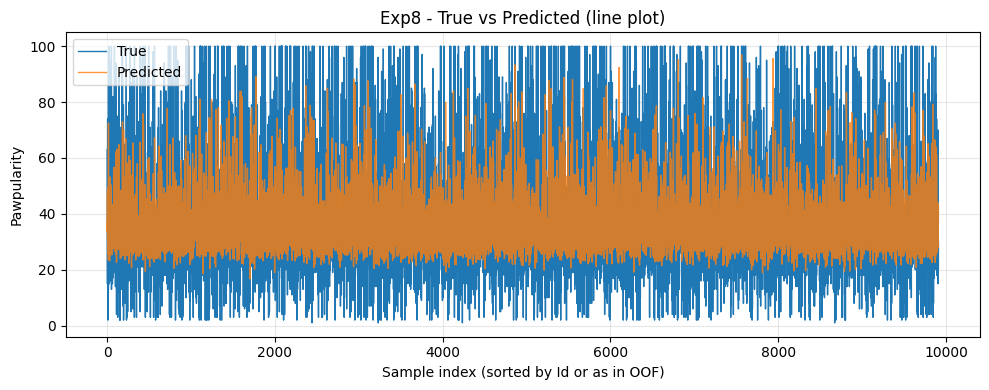

In [8]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plots
plot_oof_true_pred_lines(oof_df, title_prefix="Exp8")



Exp2_EffB0_NoFusion OOF RMSE: 19.177387932516293
Exp8_EffB4_NoFusion OOF RMSE: 18.682241951546622
ΔRMSE (Exp8_EffB4_NoFusion - Exp2_EffB0_NoFusion): -0.4951459809696708


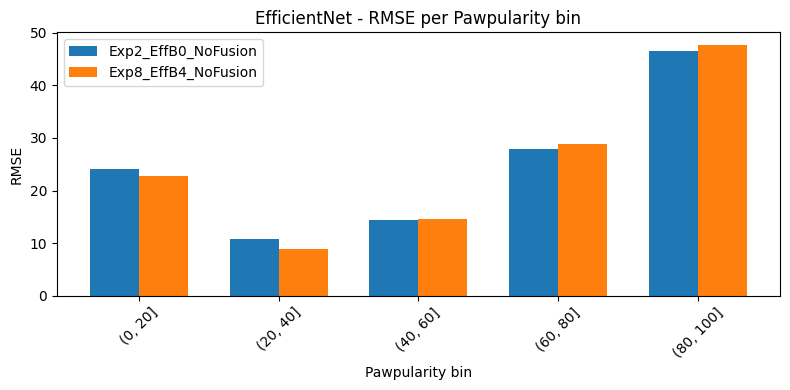

In [9]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a="../outputs/exp2/oof_detail.csv",
    oof_path_b="../outputs/exp8/oof_detail.csv",
    bins=bins,
    label_a="Exp2_EffB0_NoFusion",
    label_b="Exp8_EffB4_NoFusion",
    title_prefix="EfficientNet",
)

Exp8_EffB4_NoFusion_LiteAug OOF RMSE: 19.069219459958898
Exp8_EffB4_NoFusion_StrongAug OOF RMSE: 18.682241951546622
ΔRMSE (Exp8_EffB4_NoFusion_StrongAug - Exp8_EffB4_NoFusion_LiteAug): -0.38697750841227574


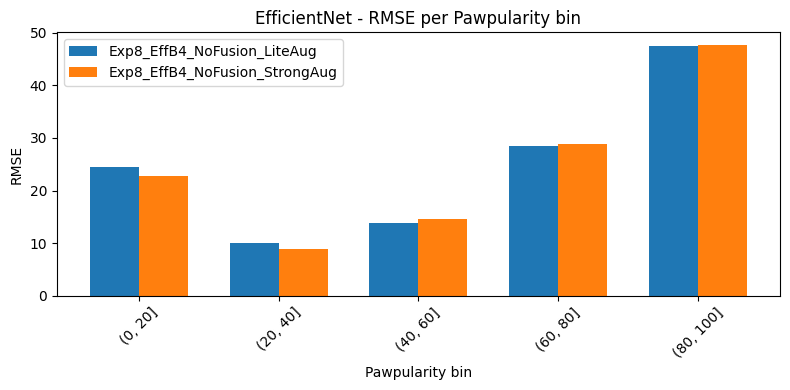

In [11]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a="../outputs/extra/exp8_256_effB4_liteAug/oof_detail.csv",
    oof_path_b="../outputs/exp8/oof_detail.csv",
    bins=bins,
    label_a="Exp8_EffB4_NoFusion_LiteAug",
    label_b="Exp8_EffB4_NoFusion_StrongAug",
    title_prefix="EfficientNet",
)

In [12]:
df_bins.head()

,bin,count,Exp8_EffB4_NoFusion_LiteAug_rmse,Exp8_EffB4_NoFusion_StrongAug_rmse,rmse_diff,winner
0,"(0, 20]",1417,24.426563,22.815533,-1.611030,Exp8_EffB4_NoFusion_StrongAug_better
1,"(20, 40]",5119,10.000162,8.891782,-1.108379,Exp8_EffB4_NoFusion_StrongAug_better
2,"(40, 60]",2088,13.779298,14.525071,0.745773,Exp8_EffB4_NoFusion_LiteAug_better
3,"(60, 80]",727,28.393745,28.761188,0.367443,Exp8_EffB4_NoFusion_LiteAug_better
4,"(80, 100]",561,47.474817,47.678782,0.203964,Exp8_EffB4_NoFusion_LiteAug_better


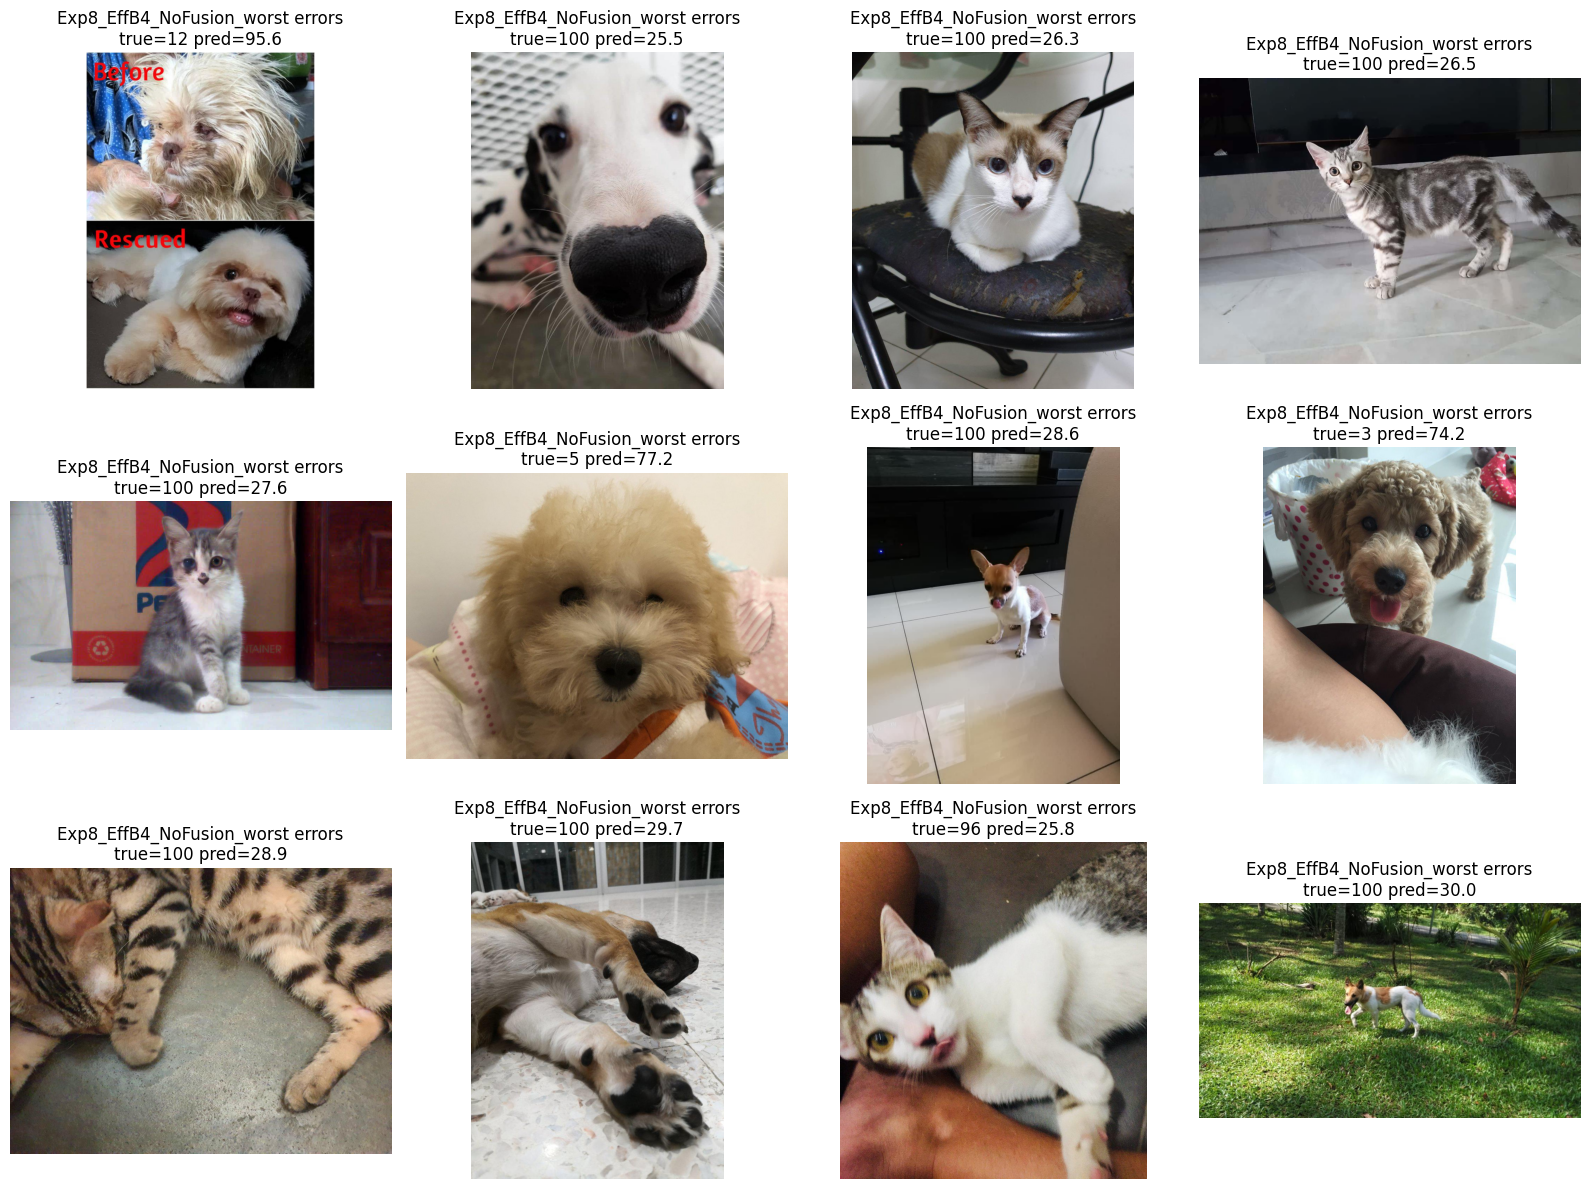

In [11]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="Exp8_EffB4_NoFusion_worst errors")

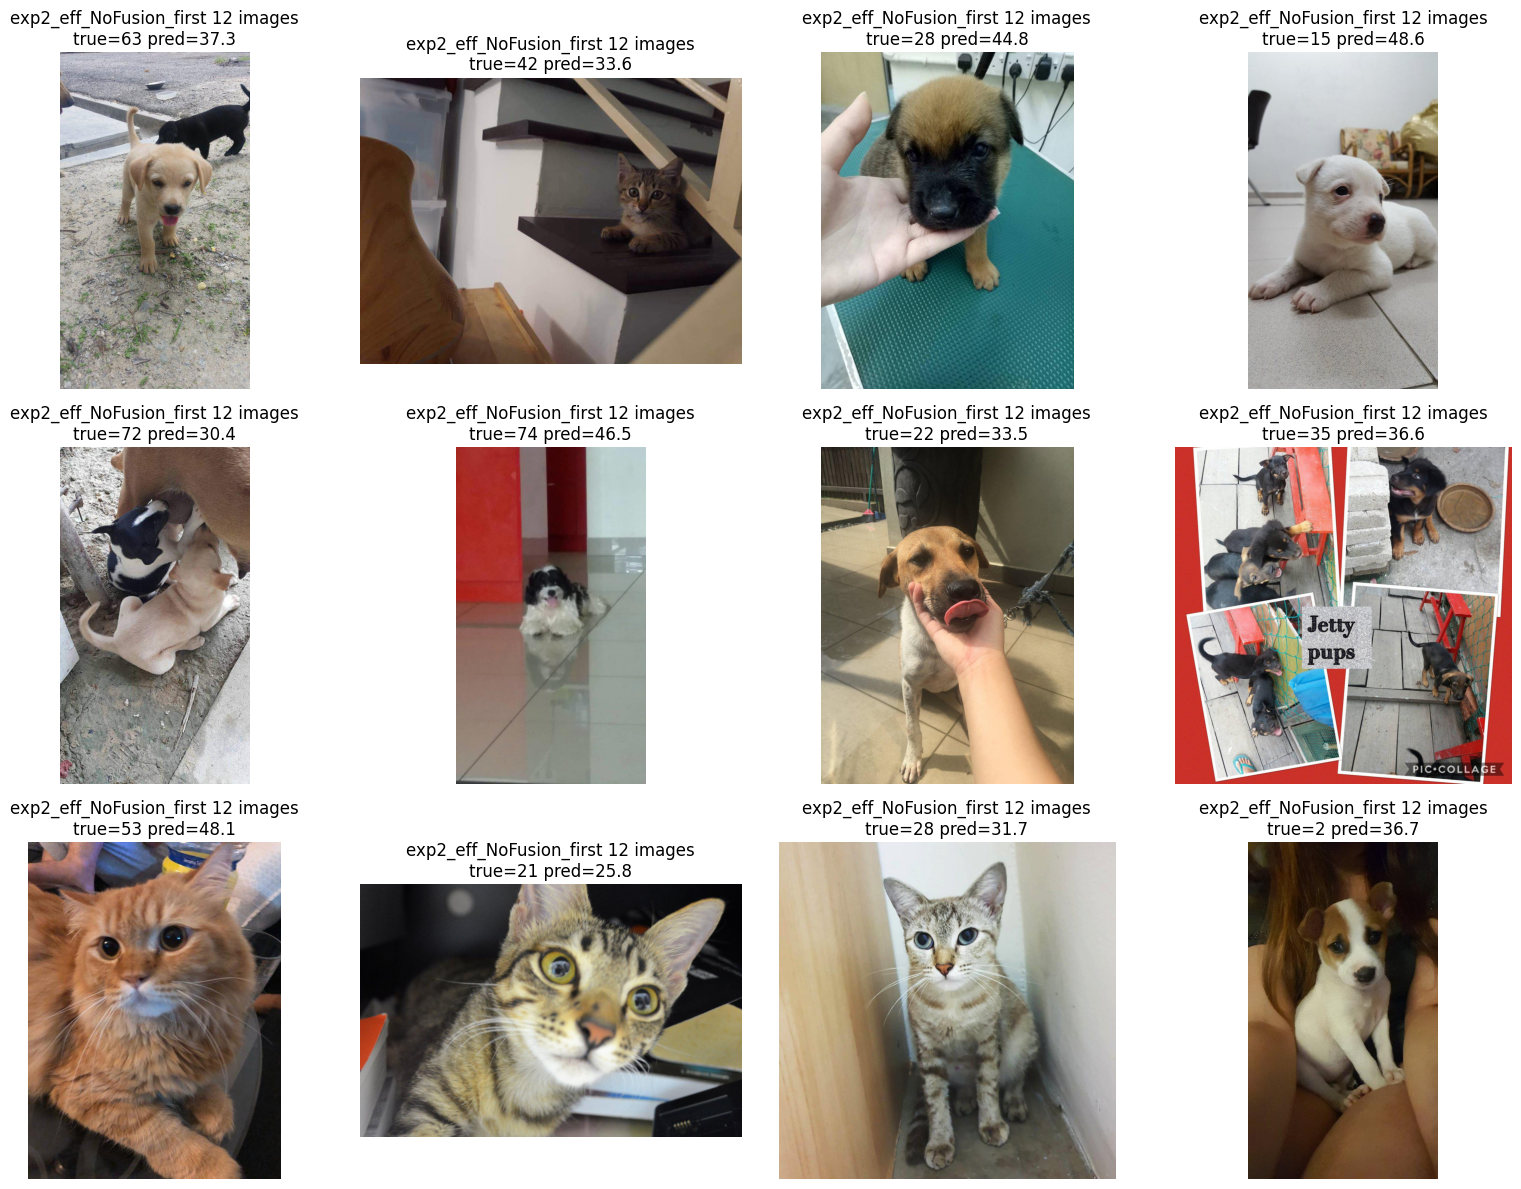

In [12]:
show_images_grid(oof_df, img_folder, n=12, title_prefix="exp2_eff_NoFusion_first 12 images")